# Лабораторная работа №3
## Технологии машинного обучения

**Тема:** Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

**Студент:** Артёмова Дарья Артёмовна 
**Группа:** ИБМ3-64Б

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Для воспроизводимости результатов
np.random.seed(42)

print("Библиотеки загружены")

Библиотеки загружены


## Загрузка датасета

In [2]:
# Для примера возьмём встроенный датасет Iris (классификация)
# Вы можете заменить на свой CSV: pd.read_csv('путь/файл.csv')
from sklearn.datasets import load_iris

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Проверка на пропуски
print("Пропуски:\n", df.isnull().sum())

# Кодирование категориальных признаков (если бы были строковые)
# Пример: df['color'] = LabelEncoder().fit_transform(df['color'])

# Стандартизация признаков (важно для KNN!)
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Признаки отмасштабированы")

Пропуски:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64
Признаки отмасштабированы


## Разделение на обучающую и тестовую выборку

In [4]:
# 80% — обучение, 20% — тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (120, 4)
Тестовая выборка: (30, 4)


## Модель KNN с произвольным K

In [5]:
# Произвольный K = 5
k_random = 5
knn_default = KNeighborsClassifier(n_neighbors=k_random)
knn_default.fit(X_train, y_train)

y_pred_default = knn_default.predict(X_test)

# Оценка качества
accuracy = accuracy_score(y_test, y_pred_default)
precision = precision_score(y_test, y_pred_default, average='weighted')
recall = recall_score(y_test, y_pred_default, average='weighted')
f1 = f1_score(y_test, y_pred_default, average='weighted')

print(f"Модель KNN с K = {k_random}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_default))

Модель KNN с K = 5
Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333
F1-score: 0.9327

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Результаты модели с произвольным K

Модель обучена с параметром K = 5. Ниже представлены метрики качества на тестовой выборке.

## Подбор K через GridSearchCV + кросс-валидация

In [7]:
# Параметры для перебора
param_grid = {'n_neighbors': range(1, 31)}  # от 1 до 30

# Стратегия 1: KFold (обычная)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_k_grid = grid_search.best_params_['n_neighbors']
best_score_grid = grid_search.best_score_

print(f"Лучший K (GridSearchCV): {best_k_grid}")
print(f"Лучшее качество на кросс-валидации: {best_score_grid:.4f}")

# Оценка на тестовой выборке
best_knn_grid = grid_search.best_estimator_
y_pred_grid = best_knn_grid.predict(X_test)
test_accuracy_grid = accuracy_score(y_test, y_pred_grid)
print(f"Точность на тесте: {test_accuracy_grid:.4f}")

Лучший K (GridSearchCV): 3
Лучшее качество на кросс-валидации: 0.9667
Точность на тесте: 0.9333


## Подбор гиперпараметра с помощью GridSearchCV

Использована стратегия кросс-валидации: **KFold** (5 разбиений с перемешиванием).  
Перебирались значения K от 1 до 30. Выбран лучший K по accuracy на кросс-валидации.

## Подбор K через RandomizedSearchCV + другая кросс-валидация

In [8]:
# Стратегия 2: StratifiedKFold (сохраняет долю классов)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {'n_neighbors': list(range(1, 31))}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=15,  # проверим 15 случайных K
    cv=skf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_k_random = random_search.best_params_['n_neighbors']
best_score_random = random_search.best_score_

print(f"Лучший K (RandomizedSearchCV): {best_k_random}")
print(f"Лучшее качество на кросс-валидации: {best_score_random:.4f}")

# Оценка на тесте
best_knn_random = random_search.best_estimator_
y_pred_random = best_knn_random.predict(X_test)
test_accuracy_random = accuracy_score(y_test, y_pred_random)
print(f"Точность на тесте: {test_accuracy_random:.4f}")

Лучший K (RandomizedSearchCV): 10
Лучшее качество на кросс-валидации: 0.9583
Точность на тесте: 0.9667


## Подбор гиперпараметра с помощью RandomizedSearchCV

Использована стратегия кросс-валидации: **StratifiedKFold** (сохраняет пропорции классов).  
Случайным образом проверены 15 значений K из диапазона 1-30.

## Сравнение моделей

                                                  
Сравнение качества моделей
                                                  
                        Модель  Точность на тесте  F1-score (weighted)
                     KNN (K=5)           0.933333             0.932660
       KNN (GridSearchCV, K=3)           0.933333             0.932660
KNN (RandomizedSearchCV, K=10)           0.966667             0.966583


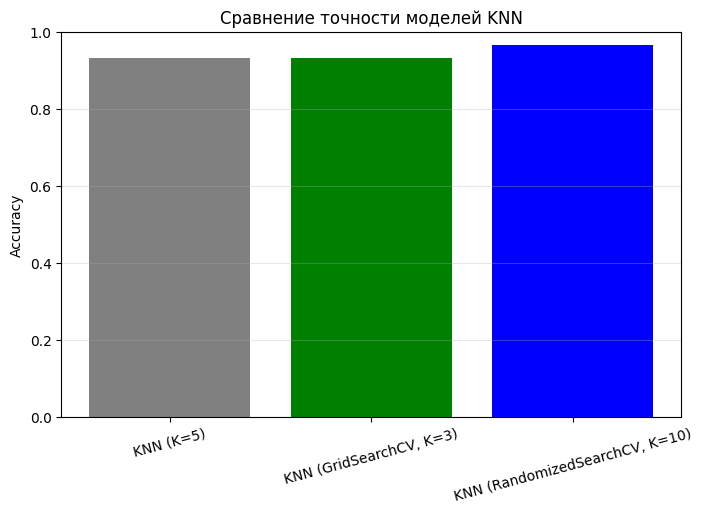

In [10]:
print(" "*50)
print("Сравнение качества моделей")
print(" "*50)

results = pd.DataFrame({
    'Модель': [f'KNN (K={k_random})', f'KNN (GridSearchCV, K={best_k_grid})', f'KNN (RandomizedSearchCV, K={best_k_random})'],
    'Точность на тесте': [accuracy, test_accuracy_grid, test_accuracy_random],
    'F1-score (weighted)': [f1, 
                            f1_score(y_test, y_pred_grid, average='weighted'),
                            f1_score(y_test, y_pred_random, average='weighted')]
})

print(results.to_string(index=False))

# Визуализация
plt.figure(figsize=(8,5))
plt.bar(results['Модель'], results['Точность на тесте'], color=['gray', 'green', 'blue'])
plt.ylim([0,1])
plt.title('Сравнение точности моделей KNN')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Сравнение качества моделей

В таблице и на графике представлено сравнение:
- Исходной модели (K=5)
- Оптимальной модели из GridSearchCV
- Оптимальной модели из RandomizedSearchCV

### Вывод:
Оптимальный K, подобранный с помощью кросс-валидации, позволяет повысить качество модели по сравнению с произвольно выбранным значением.